## <div align="center">**SSC5974 - Métodos Computacionais Aplicados ao Mercado Financeiro**</div>
## <div align="center">**Trabalho 2 - Parte 1 - Alocação de Classes**</div>
## <div align="center">**Matheus Queiroz Mota - 16767388**</div>

### **Fatores Preditivos Criados (Nem todos Foram Utilizados)**

O modelo de aprendizado supervisionado incorporou fatores macroeconômicos e estatísticos para prever a alocação ideal. As *features* foram agrupadas nas seguintes famílias conceituais:

* **Risco e Volatilidade (`VOLAT6` / `VOLAT12`):** Mapeiam a dispersão e o risco histórico dos movimentos de preço no curto e longo prazo, atuando como um radar estatístico para o modelo.
* **Estresse de Mercado (`DRAWDOWN12`):** Mede o risco de cauda e a severidade das quedas, auxiliando o modelo a diferenciar correções normais de crises estruturais, por 12 Meses.
* **Momentum (`MOM1` / `MOM3` / `MOM6`):** Composta por indicadores que capturam a força e as tendências de direcionalidade do mercado no curto e médio prazo.
* **Custo de Oportunidade (`PREMIO_RISCO`):** Compara retornos para avaliar matematicamente o excesso de prêmio, indicando se a exposição a ativos de risco é atrativa no cenário atual.
* **Cinemática de Preço (`ACELERACAO`):** Mede a variação das forças de mercado, sinalizando precocemente se uma tendência está ganhando força ou entrando em processo de exaustão.

### **Metodologia de Classificação dos Modelos**

Para consolidar os múltiplos indicadores em decisões de alocação, a estratégia testou algoritmos distintos de Aprendizado de Máquina, cada um com uma mecânica própria de interpretação dos fatores:

* **Árvores Aleatórias (Random Forest):** Utiliza um *ensemble* (conjunto) de árvores de decisão independentes baseadas em *bagging* para encontrar padrões, mitigando o sobreajuste (*overfitting*) através da restrição proposital de profundidade (`max_depth=3`).
* **Gradient Boosting (XGBoost):** Constrói árvores de forma sequencial, onde cada novo modelo foca em corrigir exclusivamente os erros residuais de classificação das instâncias anteriores, utilizando uma convergência gradual.
* **Redes Neurais Artificiais (MLP Classifier):** Emprega uma arquitetura minimalista de neurônios com forte regularização para extrair padrões não-lineares. Exigiu o uso do *StandardScaler* em seu *pipeline* para padronizar os fatores.

### **Abordagem Utilizada na Formação do Treinamento**

Para garantir a consistência das previsões, os algoritmos operaram sob o seguinte rigor metodológico:

* **Saída Multiclasse (Target):** O problema foi modelado como uma classificação multiclasse. O objetivo central do algoritmo era identificar qual dos três ativos principais da carteira (IBOV, SELIC-ACC ou USD) entregaria a maior rentabilidade no período seguinte, atribuindo a classe vencedora (0, 1 ou 2) à amostra.
* **Correção de Viés Temporal:** Implementação de deslocamento temporal negativo (método `shift(-1)`) na matriz de retornos para garantir que as variáveis explicativas do mês atual estivessem alinhadas apenas com o desfecho financeiro do mês futuro, eliminando o *look-ahead bias* (viés de antecipação).
* **Validação Cronológica:** Tratando-se de séries temporais financeiras, a divisão da base de dados respeitou estritamente a linha do tempo. Os algoritmos foram treinados exclusivamente com os primeiros meses da série histórica, preservando o período *Out-of-Sample* (teste) de forma íntegra para a avaliação final.

In [26]:
from sklearn import tree
from sklearn import metrics
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
sns.set(style='whitegrid')

In [27]:
dados=pd.read_excel('v6-DB-Indices.xlsx', engine='openpyxl')
dados.set_index(keys = 'Data', inplace = True)


In [28]:
dados_chg = dados.pct_change()
dados_chg.fillna(0, inplace=True)

In [29]:
def Criar_features(dados, dados_chg, lista_ativos, lista_features, ativo_seguranca='SELIC-ACC'):
    """
    Gera indicadores quantitativos apenas para as features explicitamente solicitadas.
    Opções de features: 'MOM1', 'MOM3', 'MOM6', 'VOLAT6', 'VOLAT12', 'DRAWDOWN', 'ACELERACAO', 'PREMIO_RISCO'
    """
    df_feat = pd.DataFrame(index=dados.index)
    
    
    if 'PREMIO_RISCO' in lista_features:
        selic_mom3 = dados[ativo_seguranca] / dados[ativo_seguranca].shift(3) - 1
    
    for ativo in lista_ativos:
        
        #  Família Momentum 
        if 'MOM1' in lista_features:
            df_feat[f'{ativo}_MOM1'] = dados[ativo] / dados[ativo].shift(1)# - 1
            
        if 'MOM3' in lista_features:
            df_feat[f'{ativo}_MOM3'] = dados[ativo] / dados[ativo].shift(3)# - 1
            
        if 'MOM6' in lista_features:
            df_feat[f'{ativo}_MOM6'] = dados[ativo] / dados[ativo].shift(6)# - 1
            
        #  Família Volatilidade 
        if 'VOLAT6' in lista_features:
            df_feat[f'{ativo}_VOLAT6'] = dados_chg[ativo].rolling(window=6).std()
            
        if 'VOLAT12' in lista_features:
            df_feat[f'{ativo}_VOLAT12'] = dados_chg[ativo].rolling(window=12).std()
            
        #  Família Estresse 
        if 'DRAWDOWN' in lista_features:
            topo_12m = dados[ativo].rolling(window=12).max()
            df_feat[f'{ativo}_DRAWDOWN'] = (dados[ativo] / topo_12m) - 1
            
        #  Família Cinemática 
        if 'ACELERACAO' in lista_features:
            # Calculamos na hora para garantir que funciona mesmo se o usuário não pedir MOM1 e MOM3
            mom1_temp = dados[ativo] / dados[ativo].shift(1) - 1
            mom3_temp = dados[ativo] / dados[ativo].shift(3) - 1
            df_feat[f'{ativo}_ACELERACAO'] = mom1_temp - mom3_temp
            
        #  Família Custo de Oportunidade 
        if 'PREMIO_RISCO' in lista_features and ativo != ativo_seguranca:
            mom3_temp = dados[ativo] / dados[ativo].shift(3) - 1
            df_feat[f'{ativo}_PREMIO_RISCO'] = mom3_temp - selic_mom3

    df_feat = df_feat.fillna(0)
    
    return df_feat, list(df_feat.columns)

In [30]:
def criar_alvos(dados_chg, lista_ativos, ativo_seguranca='SELIC-ACC'):
    """
    Gera a matriz binária (One-Hot) de alvos de compra.
    O deslocamento temporal será feito no split de treino/validação.
    """
    df_alvos = pd.DataFrame(index=dados_chg.index)
    
    # Identifica o vencedor de cada mês (igual ao professor)
    vencedores = dados_chg[lista_ativos].idxmax(axis=1)
    
    for ativo in lista_ativos:
        nome_coluna = f'{ativo}-BUY'
        
        # Marca o vencedor do mês atual (sem shift aqui)
        df_alvos[nome_coluna] = np.where(vencedores == ativo, 1, 0)
        
        # Preenche os primeiros NaNs (sem shift ainda)
        if ativo == ativo_seguranca:
            df_alvos[nome_coluna] = df_alvos[nome_coluna].fillna(1)
        else:
            df_alvos[nome_coluna] = df_alvos[nome_coluna].fillna(0)
            
    return df_alvos, list(df_alvos.columns)

### **Observação:**

No código abaixo ao executar a função ***Criar_features()*** irá gerar todas as combinações entre os fatores e features, ex: USD_MOM3, IBOV_MOM3, etc.

Deste modo, para evitar ter dezenas de variáveis no modelo, optei por selecionar apenas:

- **['IBOV_MOM1', 'IBOV_MOM3','USD_ACELERACAO','IBOV_VOLAT12','USD_MOM3']**

In [ ]:
# Ativos Escolhidos Neste Teste
ativos = ['IBOV', 'SELIC-ACC','USD']

# Aqui ele gera todas as combinações possíveis de Ativo_Feature, mas irei selecionar apenas algumas
features_desejadas = ['MOM1', 'VOLAT12', 'DRAWDOWN','ACELERACAO','PREMIO_RISCO','MOM3','MOM6']


dados_X, colunas_features = Criar_features(
    dados=dados, 
    dados_chg=dados_chg, 
    lista_ativos=ativos, 
    lista_features=features_desejadas, # <--- A mágica acontece aqui
    ativo_seguranca='SELIC-ACC'
)

# Seleção das Principais Features
dados_X_modelo1 = dados_X[['IBOV_MOM1', 'IBOV_MOM3','USD_ACELERACAO','IBOV_VOLAT12','USD_MOM3']]
dados_X_modelo1.head()

df_y_modelo1, colunas_y_modelo_1 = criar_alvos(dados_chg, ['IBOV', 'SELIC-ACC','USD'], ativo_seguranca='SELIC-ACC')

Xmod1 = dados_X_modelo1.to_numpy()
y_mod1 = df_y_modelo1.to_numpy()
dados_apr = pd.concat([dados_chg[ativos],dados_X_modelo1,df_y_modelo1],axis=1)


In [32]:
dados_apr.iloc[12:,:]

,IBOV,SELIC-ACC,USD,IBOV_MOM1,IBOV_MOM3,USD_ACELERACAO,IBOV_VOLAT12,USD_MOM3,IBOV-BUY,SELIC-ACC-BUY,USD-BUY
Data,,,,,,,,,,,
Dez-2000,0.148416,0.011982,-0.002143,1.148416,0.957998,-0.062728,0.088868,1.060585,1,0,0
Jan-2001,0.158136,0.012651,0.008029,1.158136,1.188673,-0.024501,0.099635,1.032530,1,0,0
Fev-2001,-0.100781,0.010158,0.037593,0.899219,1.195981,-0.006089,0.102037,1.043682,0,0,1
Mar-2001,-0.091435,0.012579,0.056914,0.908565,0.946196,-0.048538,0.104942,1.105452,0,0,1
Abr-2001,0.033176,0.011864,0.010687,1.033176,0.844104,-0.097679,0.098940,1.108366,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...
Jan-2026,0.125607,0.011642,-0.049487,1.125607,1.212808,-0.020849,0.044227,0.971361,1,0,0
Fev-2026,0.040929,0.009970,-0.015411,1.040929,1.186801,0.019142,0.040292,0.965447,1,0,0
Mar-2026,-0.007019,0.012121,0.013574,0.992981,1.163453,0.065006,0.041424,0.948568,0,0,1


In [33]:
n_train=180
# O shift tempral será aplicado aqui, como visto em sala.

train_in_m1 =  Xmod1[12 : 12+n_train]
train_out_m1 = y_mod1[13 : 13+n_train] 

val_in_m1 =  Xmod1[12+n_train : len(y_mod1)-1]
val_out_m1 = y_mod1[13+n_train : len(y_mod1)] 

y_train_1d = np.argmax(train_out_m1, axis=1)

# Modelos:
# Os demais parâmetros são os padrões das Bibliotecas
clf_rf = RandomForestClassifier(max_depth=3,random_state=42)

clf_xgb = XGBClassifier(max_depth=5, learning_rate=0.1,random_state=42)

clf_mlp = make_pipeline(
    StandardScaler(), 
    MLPClassifier(
        hidden_layer_sizes=(5,), 
        max_iter=100000, 
        solver='lbfgs', 
        activation='tanh', 
        alpha=0.5, 
        tol=0.01, random_state=42
    )
)

# tREINO
clf_rf.fit(train_in_m1, y_train_1d)
clf_xgb.fit(train_in_m1, y_train_1d)
clf_mlp.fit(train_in_m1, y_train_1d)

,steps,"[('standardscaler', ...), ('mlpclassifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,hidden_layer_sizes,"(5,)"
,activation,'tanh'
,solver,'lbfgs'
,alpha,0.5


In [34]:
y_val_1d = np.argmax(val_out_m1, axis=1)

# Predições
y_pred_rf  = clf_rf.predict(val_in_m1)
y_pred_xgb = clf_xgb.predict(val_in_m1)
y_pred_mlp = clf_mlp.predict(val_in_m1)

# Acurácia
acc_rf  = accuracy_score(y_val_1d, y_pred_rf)
acc_xgb = accuracy_score(y_val_1d, y_pred_xgb)
acc_mlp = accuracy_score(y_val_1d, y_pred_mlp)

# Desempenho
print("=" * 45)
print("ACURÁCIA DOS MODELOS (Período de Validação)")
print("=" * 45)
print(f"Random Forest : {acc_rf * 100:.2f}% de acertos diretos")
print(f"XGBoost       : {acc_xgb * 100:.2f}% de acertos diretos")
print(f"MlpBoost      : {acc_mlp * 100:.2f}% de acertos diretos")
print("=" * 45)


ACURÁCIA DOS MODELOS (Período de Validação)
Random Forest : 48.00% de acertos diretos
XGBoost       : 40.80% de acertos diretos
MlpBoost      : 45.60% de acertos diretos


In [35]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd

# Previsão no Treino e Teste
previsoes = {
    'Modelo_RF': clf_rf.predict(Xmod1),
    'Modelo_XGB': clf_xgb.predict(Xmod1),
    'Modelo_MLP': clf_mlp.predict(Xmod1) 
}


# Calculos de Rentabilidade: Note que aqui é necessário aplicar o shift
for nome_modelo, previso_full in previsoes.items():
    dados_apr[nome_modelo] = 0.0
    
    for i, ativo in enumerate(ativos):
        coluna_buy = (previso_full == i).astype(int)
        coluna_buy_shifted = pd.Series(coluna_buy).shift(1).fillna(0)
        dados_apr[nome_modelo] += dados_apr[ativo].values * coluna_buy_shifted.values




### **Metodologia de Avaliação de Desempenho e Risco**

Para aferir a performance dos modelos de forma realista no período de validação (*Out-of-Sample*), as seguintes métricas foram adotadas:

* **Retorno Acumulado Líquido:** Mede o ganho percentual real da estratégia isolando estritamente o período de teste. A composição dos juros se inicia do zero no "Dia 1" da validação, garantindo que a curva de capital não carregue a memória de lucros ilusórios obtidos durante a fase de treinamento da máquina.
* **Retorno Anualizado Móvel (12 Meses):** Avalia a rentabilidade em janelas deslizantes de um ano. Esta abordagem serve para comprovar a consistência da estratégia ao longo do tempo, evidenciando se a IA performa bem de maneira contínua ou se dependeu de eventos isolados de sorte.
* **Volatilidade Anualizada Móvel:** Mede a instabilidade e o risco da carteira também em janelas contínuas de 12 meses. O objetivo é evidenciar visualmente se o modelo foi capaz de identificar o perigo e proteger o capital durante as crises de mercado.
* **Rebaixamento Máximo (*Drawdown*):** Representa o risco de cauda (*downside risk*). A métrica rastreia a maior queda percentual sofrida pela carteira em relação ao seu topo histórico anterior, revelando o pior cenário de perda patrimonial que um investidor teria enfrentado.
* **Retorno/Volatilidade:** Utilizado para a consolidação global de resultados, mede a eficiência operacional. A métrica relaciona o retorno entregue pela volatilidade sofrida, permitindo classificar com justiça qual modelo extrai o maior lucro para cada unidade de risco assumida.

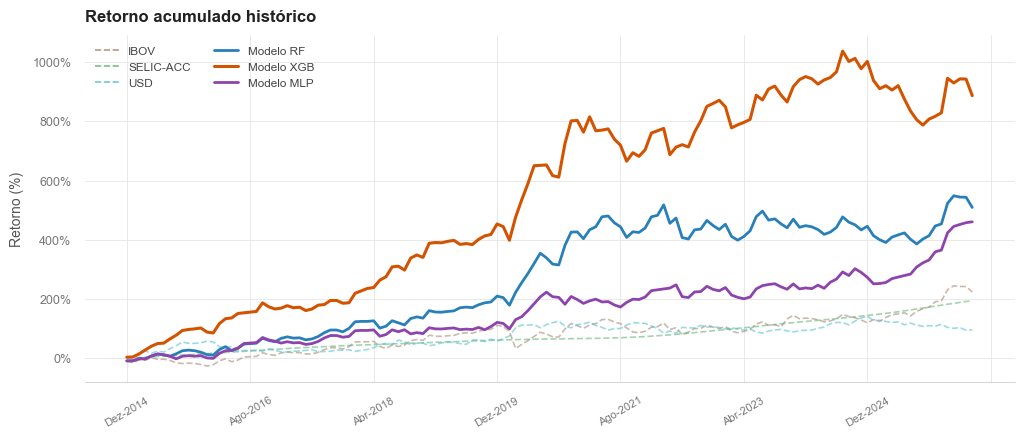

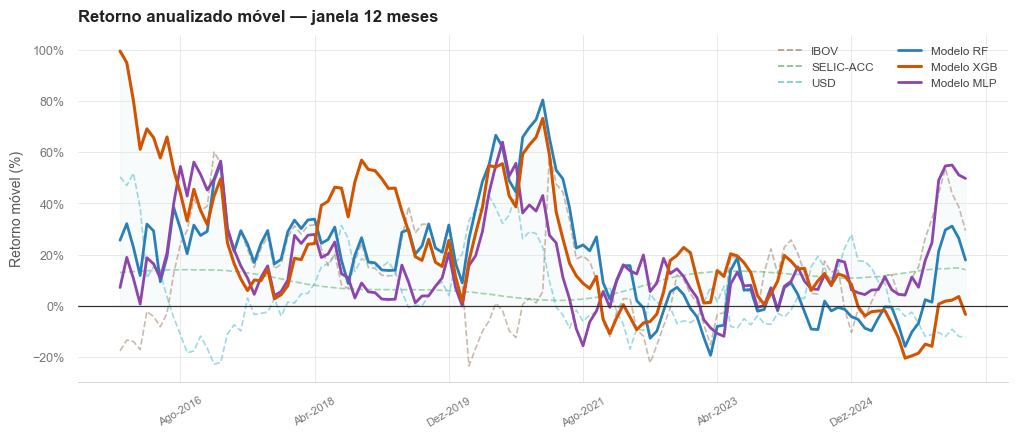

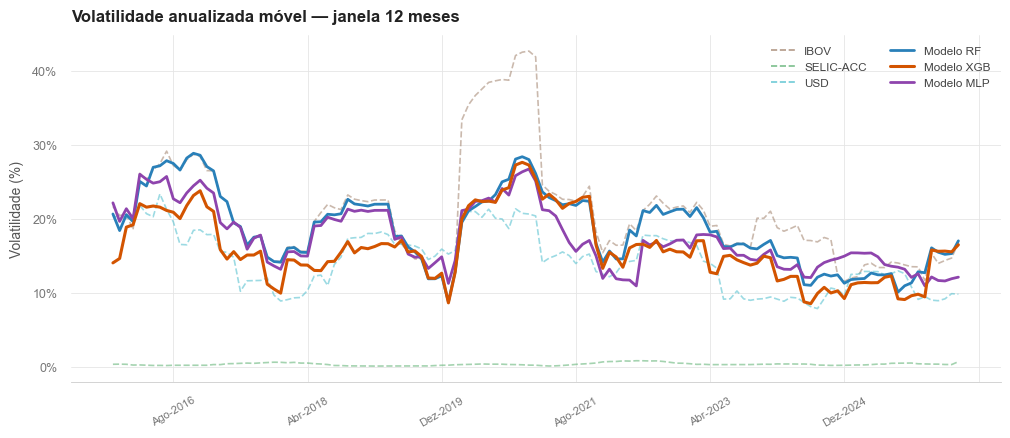

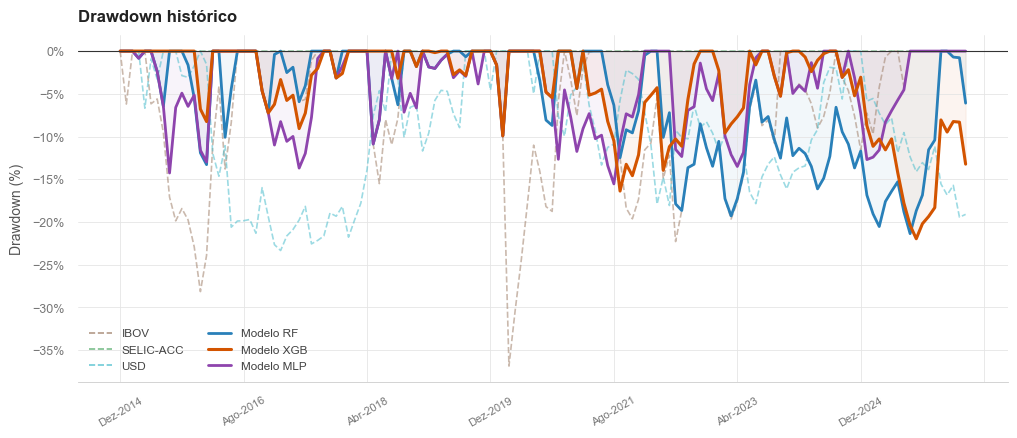

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.lines import Line2D

plt.rcParams.update({
    'font.family':      'sans-serif',
    'font.size':        10,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.spines.left': False,
    'axes.grid':        True,
    'grid.color':       '#e5e5e5',
    'grid.linewidth':   0.6,
    'grid.linestyle':   '-',
    'axes.axisbelow':   True,
    'xtick.bottom':     False,
    'ytick.left':       False,
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
})

CORES = {
    'IBOV':       '#A0806A',   
    'SELIC-ACC':  '#5AAF6F',   
    'USD':        '#4BBDCC',   
    'Modelo_RF':  '#2980B9',   
    'Modelo_XGB': '#D35400',   
    'Modelo_MLP': '#8E44AD',   
}

ESTILOS = {
    'IBOV':       dict(ls='--', lw=1.2, alpha=0.55, zorder=1),
    'SELIC-ACC':  dict(ls='--', lw=1.2, alpha=0.55, zorder=1),
    'USD':        dict(ls='--', lw=1.2, alpha=0.55, zorder=1),
    'Modelo_RF':  dict(ls='-',  lw=2.0, alpha=1.00, zorder=3),
    'Modelo_XGB': dict(ls='-',  lw=2.2, alpha=1.00, zorder=4),
    'Modelo_MLP': dict(ls='-',  lw=2.0, alpha=1.00, zorder=3),
}

ativos   = ['IBOV', 'SELIC-ACC', 'USD']
modelos  = ['Modelo_RF', 'Modelo_XGB', 'Modelo_MLP']
colunas  = ativos + modelos

def _legenda_handles():
    handles = []
    for col in colunas:
        h = Line2D([0], [0],
                   color=CORES[col],
                   linestyle=ESTILOS[col]['ls'],
                   linewidth=ESTILOS[col]['lw'],
                   alpha=max(ESTILOS[col]['alpha'], 0.8),
                   label=col.replace('_', ' '))
        handles.append(h)
    return handles

def _aplicar_estilo(ax, ylabel, pct=True):

    if pct:
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
    ax.set_ylabel(ylabel, fontsize=10, color='#555555', labelpad=6)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30, labelsize=8, colors='#777777')
    ax.tick_params(axis='y', labelsize=9,  colors='#777777')
    ax.spines['bottom'].set_color('#cccccc')
    ax.spines['bottom'].set_linewidth(0.6)



colunas_analise = ativos + list(previsoes.keys())
df_plot = dados_apr[colunas_analise].iloc[n_train:].copy()

df_ret_acc   = (1 + df_plot).cumprod() - 1
df_ret_movel = (1 + df_plot).rolling(12).apply(np.prod, raw=True) - 1
df_vol_movel = df_plot.rolling(12).std() * np.sqrt(12)

max_acc      = (1 + df_ret_acc).cummax()
df_drawdown  = ((1 + df_ret_acc) / max_acc) - 1

#  Gráfico 1 — Retorno Acumulado 
fig, ax = plt.subplots(figsize=(12, 4.5))

for col in colunas:
    (df_ret_acc[col] * 100).plot(
        ax=ax, color=CORES[col], **ESTILOS[col], label=col.replace('_', ' '))

_aplicar_estilo(ax, 'Retorno (%)')
ax.set_title('Retorno acumulado histórico', fontsize=12, fontweight='bold',
             pad=10, loc='left', color='#222222')
ax.legend(handles=_legenda_handles(), loc='upper left',
          frameon=False, fontsize=8.5, ncol=2, labelcolor='#444444')



#  Gráfico 2 — Retorno Móvel 12M 
fig, ax = plt.subplots(figsize=(12, 4.5))

for col in colunas:
    (df_ret_movel[col] * 100).plot(
        ax=ax, color=CORES[col], **ESTILOS[col], label=col.replace('_', ' '))

ax.axhline(0, color='#333333', lw=0.9, ls='-', zorder=5)

ax.fill_between(df_ret_movel.index,
                (df_ret_movel.max(axis=1) * 100).clip(lower=0),
                0, alpha=0.03, color='#2980B9', zorder=0)

_aplicar_estilo(ax, 'Retorno móvel (%)')
ax.set_title('Retorno anualizado móvel — janela 12 meses', fontsize=12,
             fontweight='bold', pad=10, loc='left', color='#222222')
ax.legend(handles=_legenda_handles(), loc='upper right',
          frameon=False, fontsize=8.5, ncol=2, labelcolor='#444444')


#  Gráfico 3 — Volatilidade 
fig, ax = plt.subplots(figsize=(12, 4.5))

for col in colunas:
    (df_vol_movel[col] * 100).plot(
        ax=ax, color=CORES[col], **ESTILOS[col], label=col.replace('_', ' '))

_aplicar_estilo(ax, 'Volatilidade (%)')
ax.set_title('Volatilidade anualizada móvel — janela 12 meses', fontsize=12,
             fontweight='bold', pad=10, loc='left', color='#222222')
ax.legend(handles=_legenda_handles(), loc='upper right',
          frameon=False, fontsize=8.5, ncol=2, labelcolor='#444444')


#  Gráfico 4 - Drawdown
fig, ax = plt.subplots(figsize=(12, 4.5))

for col in colunas:
    serie = df_drawdown[col] * 100
    serie.plot(ax=ax, color=CORES[col], **ESTILOS[col], label=col.replace('_', ' '))
    if col in modelos:
        ax.fill_between(serie.index, serie, 0,
                        alpha=0.06, color=CORES[col], zorder=0)

ax.axhline(0, color='#333333', lw=0.8, ls='-', zorder=5)

_aplicar_estilo(ax, 'Drawdown (%)')
ax.set_title('Drawdown histórico', fontsize=12,
             fontweight='bold', pad=10, loc='left', color='#222222')
ax.legend(handles=_legenda_handles(), loc='lower left',
          frameon=False, fontsize=8.5, ncol=2, labelcolor='#444444')



### **Tabela Descritiva (Conjunto de Teste)**

In [ ]:
import pandas as pd
import numpy as np


n_meses = len(df_plot)
anos = n_meses / 12

lista_resultados = []

for coluna in df_plot.columns:
    
    # 1. Retorno Acumulado (O valor final da linha no gráfico)
    ret_acc = df_ret_acc[coluna].iloc[-1]
    
    # 2. Retorno Anualizado 
    ret_anualizado = ((1 + ret_acc) ** (1 / anos)) - 1
    
    # 3. Volatilidade Anualizada (Desvio padrão dos retornos mensais * raiz quadrada de 12)
    vol_anualizada = df_plot[coluna].std() * np.sqrt(12)
    
    # 4. Maximum Drawdown (A queda mais profunda já registrada)
    max_dd = df_drawdown[coluna].min()
    
    # 5. (Retorno vs Risco)
    sharpe_ratio = ret_anualizado / vol_anualizada if vol_anualizada != 0 else 0
    
    lista_resultados.append({
        'Estratégia / Ativo': coluna,
        'Retorno Acumulado': f"{ret_acc * 100:.2f}%",
        'Retorno Anualizado': f"{ret_anualizado * 100:.2f}%",
        'Volatilidade (a.a.)': f"{vol_anualizada * 100:.2f}%",
        'Drawdown Máximo': f"{max_dd * 100:.2f}%",
        'Retorno/Volatilidade': f"{sharpe_ratio:.2f}"
    })

tabela_descritiva = pd.DataFrame(lista_resultados).set_index('Estratégia / Ativo')

display(tabela_descritiva)

,Retorno Acumulado,Retorno Anualizado,Volatilidade (a.a.),Drawdown Máximo,Retorno/Volatilidade
Estratégia / Ativo,,,,,
IBOV,223.96%,10.76%,21.69%,-36.86%,0.50
SELIC-ACC,193.59%,9.82%,1.13%,0.00%,8.72
USD,95.67%,6.01%,15.29%,-23.34%,0.39
Modelo_RF,509.17%,17.01%,19.25%,-21.36%,0.88
Modelo_XGB,886.53%,22.02%,17.27%,-21.96%,1.28
Modelo_MLP,460.76%,16.17%,17.85%,-15.54%,0.91


### **Distribuição das Escolhas do Modelo Durante o Período de Teste**

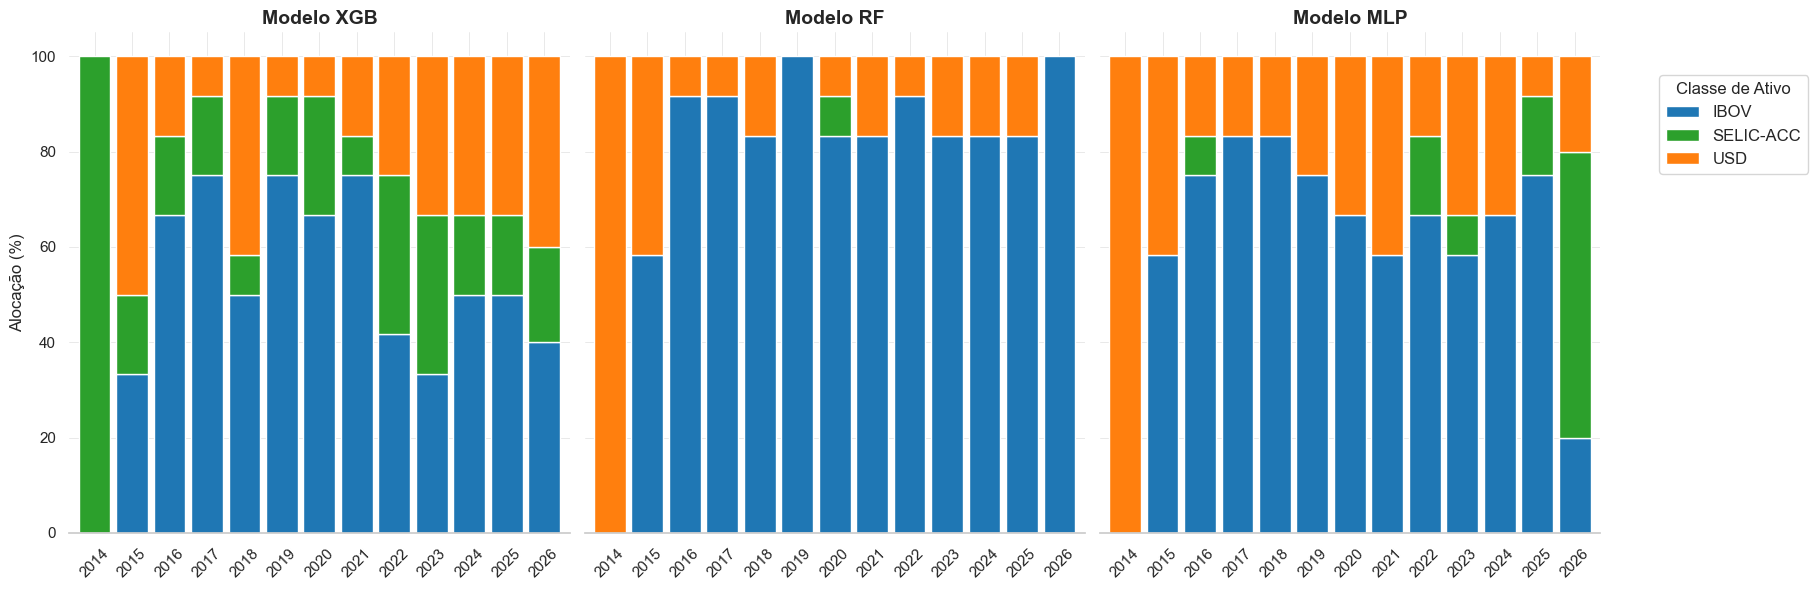

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

modelos = ['Modelo_XGB', 'Modelo_RF', 'Modelo_MLP']
mapa_ativos = {i: ativo for i, ativo in enumerate(ativos)}
cores = {'IBOV': '#1f77b4', 'SELIC-ACC': '#2ca02c', 'USD': '#ff7f0e'}


fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
fig.subplots_adjust(wspace=0.1)

for ax, modelo in zip(axes, modelos):
    sinais = previsoes[modelo][n_train:]
    df_temp = pd.DataFrame(index=dados_apr.iloc[n_train:].index)
    df_temp['Decisao'] = [mapa_ativos[sinal] for sinal in sinais]
    df_temp['Ano'] = [int(str(data)[-4:]) for data in df_temp.index]
    
    tabela = pd.crosstab(df_temp['Ano'], df_temp['Decisao'], normalize='index') * 100
    
    for ativo in ativos:
        if ativo not in tabela.columns:
            tabela[ativo] = 0.0
    tabela = tabela[ativos]
    
    tabela.plot(
        kind='bar', stacked=True, ax=ax, width=0.85, 
        color=[cores[c] for c in tabela.columns], edgecolor='white'
    )
    

    ax.set_title(f'{modelo.replace("_", " ")}', fontsize=14, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45, labelsize=11)
    
    ax.get_legend().remove()

axes[0].set_ylabel('Alocação (%)', fontsize=12)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Classe de Ativo', bbox_to_anchor=(0.92, 0.88), loc='upper left', fontsize=12)
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.savefig('g3_alocacao_modelos_horizontal.png', dpi=300, bbox_inches='tight')
plt.show()

In [39]:
print(tabela_descritiva.to_markdown())

| Estratégia / Ativo   | Retorno Acumulado   | Retorno Anualizado   | Volatilidade (a.a.)   | Drawdown Máximo   |   Retorno/Volatilidade |
|:---------------------|:--------------------|:---------------------|:----------------------|:------------------|-----------------------:|
| IBOV                 | 223.96%             | 10.76%               | 21.69%                | -36.86%           |                   0.5  |
| SELIC-ACC            | 193.59%             | 9.82%                | 1.13%                 | 0.00%             |                   8.72 |
| USD                  | 95.67%              | 6.01%                | 15.29%                | -23.34%           |                   0.39 |
| Modelo_RF            | 509.17%             | 17.01%               | 19.25%                | -21.36%           |                   0.88 |
| Modelo_XGB           | 886.53%             | 22.02%               | 17.27%                | -21.96%           |                   1.28 |
| Modelo_MLP           | 46